# NB02: 성남시 건물 추출 및 층수/높이 정보 통합

**목적**: 경기도 전체 건축물현황도(AL_D010)에서 성남시 건물만 추출하고, 높이·층수 속성 정리

**입력**:
- `00_data/AL_D010_41_20260409/*.shp` (EPSG:5186, 경기도 전체 건축물)
- `processed/seongnam_boundary.gpkg` (NB01 출력)

**출력**: `processed/seongnam_buildings.gpkg`

**AL_D010 컬럼 매핑** (A0–A28):

| 컬럼 | 의미 | 단위 |
|------|------|------|
| A2   | PNU (필지고유번호, 19자리) | — |
| A3   | 법정동코드 (10자리) | — |
| A4   | 지번주소 | — |
| A8   | 건물용도코드 | — |
| A9   | 건물용도명 | — |
| A11  | 주구조 | — |
| A12  | 건축면적 | m² |
| A13  | 사용승인일 | — |
| A14  | 연면적 | m² |
| A15  | 대지면적 | m² |
| A16  | 높이 | m |
| A17  | 건폐율 | % |
| A18  | 용적률 | % |
| A21  | 건물ID (UFID) | — |
| A24  | 건물명칭 | — |
| A26  | 지상층수 | 층 |
| A27  | 지하층수 | 층 |

In [1]:
import geopandas as gpd
import pandas as pd
from pathlib import Path

BASE = Path(r"C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam_reset")
RAW  = BASE / "00_data"
OUT  = BASE / "processed"
OUT.mkdir(exist_ok=True)

# 성남시 경계 로드 (EPSG:5179, 거리계산용)
seongnam_dong = gpd.read_file(OUT / "seongnam_boundary.gpkg", layer="dong_5179")
bounds_5179   = seongnam_dong.total_bounds
print(f"성남시 Bounds (EPSG:5179): {bounds_5179}")

성남시 Bounds (EPSG:5179): [ 958182.9834 1926109.5141  973093.1936 1941780.0392]


## 1. AL_D010 건축물현황도 로드 (성남시만)

- 경기도 전체가 3개 파일로 분할 (~2.3M 건물)
- `A3` (법정동코드)가 `'4113'`으로 시작하는 행만 읽어 메모리 절약 (`where` SQL 필터)
- CRS: **EPSG:5186** (GRS80 기반 TM) — 경계 파일의 EPSG:5179와 다름

In [2]:
%%time
bldg_dir = RAW / "AL_D010_41_20260409"
shp_files = sorted(bldg_dir.glob("*.shp"))
print(f"shapefile 수: {len(shp_files)}")

parts = []
for fpath in shp_files:
    print(f"로드 중: {fpath.name}...", end=" ")
    gdf = gpd.read_file(fpath, where="A3 LIKE '4113%'")
    print(f"{len(gdf):,}건")
    parts.append(gdf)

gdf_bldg = pd.concat(parts, ignore_index=True)
print(f"\n성남시 건물 합계: {len(gdf_bldg):,}건")
print(f"CRS: {gdf_bldg.crs}")
print(f"컬럼: {gdf_bldg.columns.tolist()}")

shapefile 수: 3
로드 중: AL_D010_41_20260409(2).shp... 382건
로드 중: AL_D010_41_20260409(3).shp... 304건
로드 중: AL_D010_41_20260409.shp... 73,867건

성남시 건물 합계: 74,553건
CRS: EPSG:5186
컬럼: ['A0', 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A16', 'A17', 'A18', 'A19', 'A20', 'A21', 'A22', 'A23', 'A24', 'A25', 'A26', 'A27', 'A28', 'geometry']
CPU times: total: 36.2 s
Wall time: 36.5 s


## 2. 컬럼 정리 및 이름 변환

In [3]:
COL_MAP = {
    "A0":  "순번",
    "A1":  "건물관리번호",
    "A2":  "PNU",
    "A3":  "법정동코드",
    "A4":  "지번주소",
    "A5":  "번지",
    "A6":  "주부속구분코드",
    "A7":  "대지구분코드",
    "A8":  "건물용도코드",
    "A9":  "건물용도명",
    "A10": "건물번호코드",
    "A11": "주구조",
    "A12": "건축면적_m2",
    "A13": "사용승인일",
    "A14": "연면적_m2",
    "A15": "대지면적_m2",
    "A16": "높이_m",
    "A17": "건폐율_pct",
    "A18": "용적률_pct",
    "A19": "도로명주소코드",
    "A20": "위반건물여부",
    "A21": "건물ID",
    "A22": "데이터기준일",
    "A23": "시군구코드",
    "A24": "건물명칭",
    "A25": "동명",
    "A26": "지상층수",
    "A27": "지하층수",
    "A28": "최종변경일",
}
gdf_bldg = gdf_bldg.rename(columns=COL_MAP)

# 구 이름 파생 (법정동코드 앞 5자리 기준)
GU_MAP = {"41131": "수정구", "41133": "중원구", "41135": "분당구"}
gdf_bldg["GU_NM"] = gdf_bldg["법정동코드"].astype(str).str[:5].map(GU_MAP)

print("컬럼 변환 완료")
print(gdf_bldg[["법정동코드","GU_NM","건물용도명","높이_m","지상층수","지하층수"]].head())

컬럼 변환 완료
        법정동코드 GU_NM              건물용도명   높이_m  지상층수  지하층수
0  4113510600   분당구           °øµ¿ÁÖÅÃ  44.10    16   1.0
1  4113510100   분당구           Á¾±³½Ã¼³  36.30     5   5.0
2  4113110800   수정구  Á¦2Á¾±Ù¸°»ýÈ°½Ã¼³  50.01    12   5.0
3  4113511100   분당구           °øµ¿ÁÖÅÃ  65.70    20   2.0
4  4113310400   중원구           °øµ¿ÁÖÅÃ  13.60     4   1.0


## 3. CRS 변환 (EPSG:5186 → 5179) & 행정동 공간 조인

AL_D010은 EPSG:5186(GRS80 기반), 경계 파일은 EPSG:5179(Bessel 기반)  
→ 건물을 5179로 변환 후 행정동 경계와 spatial join하여 `ADM_NM`, `CSV_ADMI_CD` 부여

In [4]:
%%time
# EPSG:5186 → 5179
gdf_bldg_5179 = gdf_bldg.to_crs(epsg=5179)
print(f"CRS 변환 완료: {gdf_bldg_5179.crs}")

# 행정동 경계와 spatial join (건물 centroid 기준 속도 향상)
dong_cols = seongnam_dong[["SHP_ADM_CD", "ADM_NM", "CSV_ADMI_CD", "GU_NM", "geometry"]]
gdf_bldg_5179 = gpd.sjoin(
    gdf_bldg_5179,
    dong_cols,
    predicate="within",
    how="left",
).drop(columns=["index_right", "GU_NM_right"], errors="ignore")
gdf_bldg_5179 = gdf_bldg_5179.rename(columns={"GU_NM_left": "GU_NM"})

print(f"행정동 조인 후 건물 수: {len(gdf_bldg_5179):,}건")
print(f"행정동 미매칭 (경계 밖): {gdf_bldg_5179['ADM_NM'].isna().sum():,}건")
print(gdf_bldg_5179[["ADM_NM","CSV_ADMI_CD","높이_m","지상층수","지하층수"]].head())

CRS 변환 완료: EPSG:5179
행정동 조인 후 건물 수: 74,553건
행정동 미매칭 (경계 밖): 203건
  ADM_NM  CSV_ADMI_CD   높이_m  지상층수  지하층수
0   이매1동   41135600.0  44.10    16   1.0
1    분당동   41135510.0  36.30     5   5.0
2    위례동   41131625.0  50.01    12   5.0
3    금곡동   41135662.0  65.70    20   2.0
4   은행1동   41133550.0  13.60     4   1.0
CPU times: total: 906 ms
Wall time: 942 ms


## 4. 높이·층수 현황 파악

In [5]:
total = len(gdf_bldg_5179)
has_height  = (gdf_bldg_5179["높이_m"] > 0).sum()
has_floors  = (gdf_bldg_5179["지상층수"] > 0).sum()
has_bfloors = (gdf_bldg_5179["지하층수"] > 0).sum()

print(f"전체 건물: {total:,}건")
print(f"높이 정보 있음:   {has_height:,}건 ({100*has_height/total:.1f}%)")
print(f"지상층수 정보 있음: {has_floors:,}건 ({100*has_floors/total:.1f}%)")
print(f"지하층수 정보 있음: {has_bfloors:,}건 ({100*has_bfloors/total:.1f}%)")

print("\n층수 분포 (지상층수 > 0):")
print(gdf_bldg_5179[gdf_bldg_5179["지상층수"] > 0]["지상층수"].describe().round(1))

print("\n높이(m) 분포 (높이 > 0):")
print(gdf_bldg_5179[gdf_bldg_5179["높이_m"] > 0]["높이_m"].describe().round(1))

전체 건물: 74,553건
높이 정보 있음:   24,879건 (33.4%)
지상층수 정보 있음: 52,897건 (71.0%)
지하층수 정보 있음: 40,870건 (54.8%)

층수 분포 (지상층수 > 0):
count    52897.0
mean         3.2
std          3.2
min          1.0
25%          2.0
50%          2.0
75%          3.0
max         39.0
Name: 지상층수, dtype: float64

높이(m) 분포 (높이 > 0):
count    24879.0
mean        14.8
std         12.4
min          0.9
25%          9.0
50%         11.0
75%         14.3
max        134.3
Name: 높이_m, dtype: float64


## 5. 저장 (EPSG:5179 + EPSG:4326)

In [6]:
# EPSG:5179 (거리 계산용)
gdf_bldg_5179.to_file(OUT / "seongnam_buildings.gpkg", layer="buildings_5179", driver="GPKG")

# EPSG:4326 (웹 지도/Tableau용)
gdf_bldg_4326 = gdf_bldg_5179.to_crs(epsg=4326)
gdf_bldg_4326.to_file(OUT / "seongnam_buildings.gpkg", layer="buildings_4326", driver="GPKG")

print(f"저장 완료: {OUT / 'seongnam_buildings.gpkg'}")
print(f"  - buildings_5179: {len(gdf_bldg_5179):,}건 (EPSG:5179)")
print(f"  - buildings_4326: {len(gdf_bldg_4326):,}건 (EPSG:4326)")
print(f"\n최종 컬럼: {gdf_bldg_4326.columns.tolist()}")

저장 완료: C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam_reset\processed\seongnam_buildings.gpkg
  - buildings_5179: 74,553건 (EPSG:5179)
  - buildings_4326: 74,553건 (EPSG:4326)

최종 컬럼: ['순번', '건물관리번호', 'PNU', '법정동코드', '지번주소', '번지', '주부속구분코드', '대지구분코드', '건물용도코드', '건물용도명', '건물번호코드', '주구조', '건축면적_m2', '사용승인일', '연면적_m2', '대지면적_m2', '높이_m', '건폐율_pct', '용적률_pct', '도로명주소코드', '위반건물여부', '건물ID', '데이터기준일', '시군구코드', '건물명칭', '동명', '지상층수', '지하층수', '최종변경일', 'geometry', 'GU_NM', 'SHP_ADM_CD', 'ADM_NM', 'CSV_ADMI_CD']


## 6. 시각적 검증

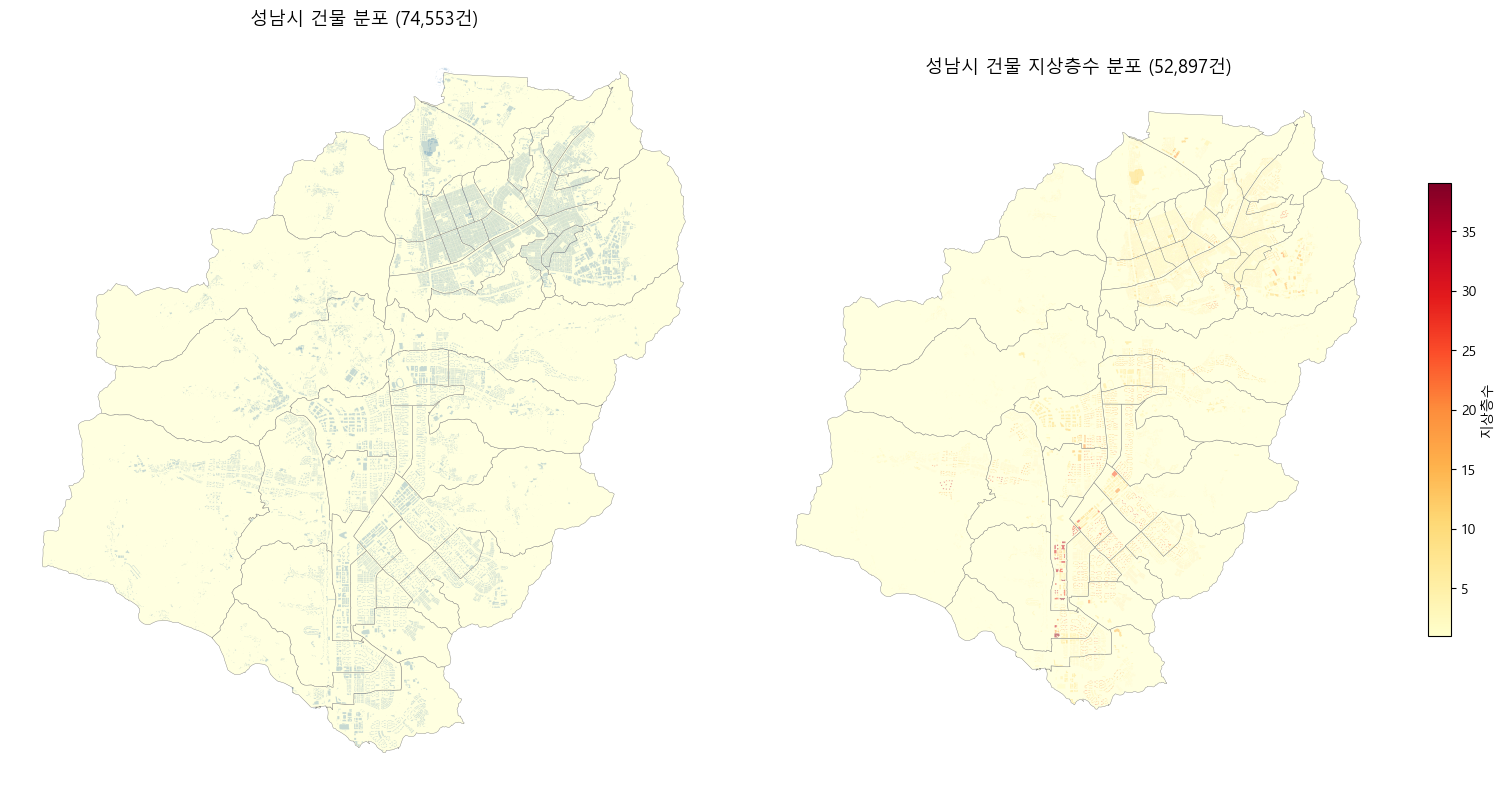

In [7]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

seongnam_4326 = seongnam_dong.to_crs(epsg=4326)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# 왼쪽: 건물 분포
seongnam_4326.plot(ax=axes[0], edgecolor="gray", facecolor="lightyellow", linewidth=0.3)
gdf_bldg_4326.plot(ax=axes[0], color="steelblue", markersize=0.05, alpha=0.3)
axes[0].set_title(f"성남시 건물 분포 ({len(gdf_bldg_4326):,}건)", fontsize=13)
axes[0].set_axis_off()

# 오른쪽: 층수 히트맵 (지상층수 > 0인 건물만)
has_fl = gdf_bldg_4326[gdf_bldg_4326["지상층수"] > 0].copy()
seongnam_4326.plot(ax=axes[1], edgecolor="gray", facecolor="lightyellow", linewidth=0.3)
has_fl.plot(
    ax=axes[1],
    column="지상층수",
    cmap="YlOrRd",
    markersize=0.2,
    alpha=0.5,
    legend=True,
    legend_kwds={"label": "지상층수", "shrink": 0.6},
)
axes[1].set_title(f"성남시 건물 지상층수 분포 ({len(has_fl):,}건)", fontsize=13)
axes[1].set_axis_off()

plt.tight_layout()
plt.show()